# 07 · Five-year rent forecast by area (Sprint 4)

**Is our historical data suitable for forecasting?** Yes, for rent levels over time we use the Victorian
Government *Rental Report* (DFFH): the quarterly moving-annual median rent of **new leases** (from bond lodgements)
for 146 areas, 2000 to 2025, built in notebook 03. That gives about 100 quarters per area.

* The listing snapshots (Domain 2025, rent.com.au 2026) are **not** a time series: two points from two websites.
  They are used for today's rent level and as a check of the forecast (last section).
* DFFH areas are groups of suburbs (e.g. "Albert Park-Middle Park-West St Kilda"). They cover 205 of the 656
  listing suburbs directly; other suburbs borrow the forecast of the nearest covered suburb (flagged).
* The moving annual median is smoothed, so it reacts to changes with a lag, and 2020–2023 contains the COVID drop
  and rebound.

**Method.** Four simple methods are compared on back-tests: we pretend it is Sept 2015 (and Sept 2020), forecast five
years ahead, and compare with what actually happened. The method with the lowest error is refitted on all data
to 2025Q3 and forecasts to 2030Q3. The uncertainty band is the back-test error of that method.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "scripts"))   # shared project code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config, style
import listings as L
style.apply()
import geo
import forecast as fc

In [2]:
panel = pd.read_parquet(config.DFFH_PANEL)
panel["quarter"] = pd.PeriodIndex(panel["quarter"].astype(str), freq="Q")
allp = panel[panel["property_type"] == "All properties"]
print(f"Quarters: {allp['quarter'].min()} to {allp['quarter'].max()} | areas: {allp['area'].nunique()} | "
      f"missing medians: {allp['median_rent'].isna().mean():.1%}")

Quarters: 2000Q1 to 2025Q3 | areas: 146 | missing medians: 0.0%


## 1. Back-test: which method would have forecast best?

In [3]:
bt = fc.backtest(panel)
summary = bt.pivot_table(index="method", columns="origin", values="abs_pct_error", aggfunc="median")
summary["average"] = summary.mean(axis=1)
bias = bt.groupby("method")["pct_error"].median().rename("typical bias (%)")
best = summary["average"].idxmin()
band = bt.loc[bt["method"] == best, "abs_pct_error"].quantile(0.8)
print(f"Best method: {best}. 80% of back-test errors were within ±{band:.0f}%, used as the forecast band.")
summary.join(bias).round(1).rename_axis("median abs. error of the 5-year forecast (%)")

Best method: trend_5y. 80% of back-test errors were within ±17%, used as the forecast band.


,2015Q3,2020Q3,average,typical bias (%)
median abs. error of the 5-year forecast (%),,,,
blend,5.3,19.6,12.4,-7.5
holt_damped,6.2,23.0,14.6,-12.9
trend_10y,13.0,16.1,14.6,-4.7
trend_5y,3.8,14.6,9.2,-8.3


`trend_5y` = continue the average growth of the last five years; `trend_10y` = of the last ten years;
`holt_damped` = exponential smoothing with a trend that slowly flattens; `blend` = average of trend_10y and Holt.
A negative bias means the method forecast too low (rents rose faster than expected after 2021).

## 2. Forecast to 2030 for every DFFH area

In [4]:
long = fc.forecast_areas(panel, best)
areas = fc.summarise(long, band)
areas.to_csv(config.CURATED / "rent_forecast_5yr_areas.csv", index=False)
print(f"{len(areas)} areas forecast. Median forecast growth: {areas['growth_pa_pct'].median():.1f}% a year")
print("Top 10 areas by forecast rent growth, 2025Q3 to 2030Q3")
areas.head(10)[["area", "rent_now", "rent_5y", "rent_5y_low", "rent_5y_high", "growth_pa_pct"]].round(1)

146 areas forecast. Median forecast growth: 6.3% a year
Top 10 areas by forecast rent growth, 2025Q3 to 2030Q3


,area,rent_now,rent_5y,rent_5y_low,rent_5y_high,growth_pa_pct
0,Morwell,380.0,627.8,518.4,737.2,10.6
1,Keilor,650.0,1030.5,850.9,1210.0,9.7
2,Moe-Newborough,390.0,608.4,502.4,714.4,9.3
3,Pakenham,540.0,833.1,688.0,978.3,9.1
4,Swan Hill,430.0,660.4,545.3,775.4,9.0
5,Shepparton,460.0,705.3,582.4,828.2,8.9
6,Bairnsdale,460.0,705.3,582.4,828.2,8.9
7,Warragul,550.0,840.3,693.9,986.7,8.8
8,Wodonga,500.0,757.6,625.6,889.6,8.7
9,Dromana-Portsea,595.0,896.3,740.1,1052.4,8.5


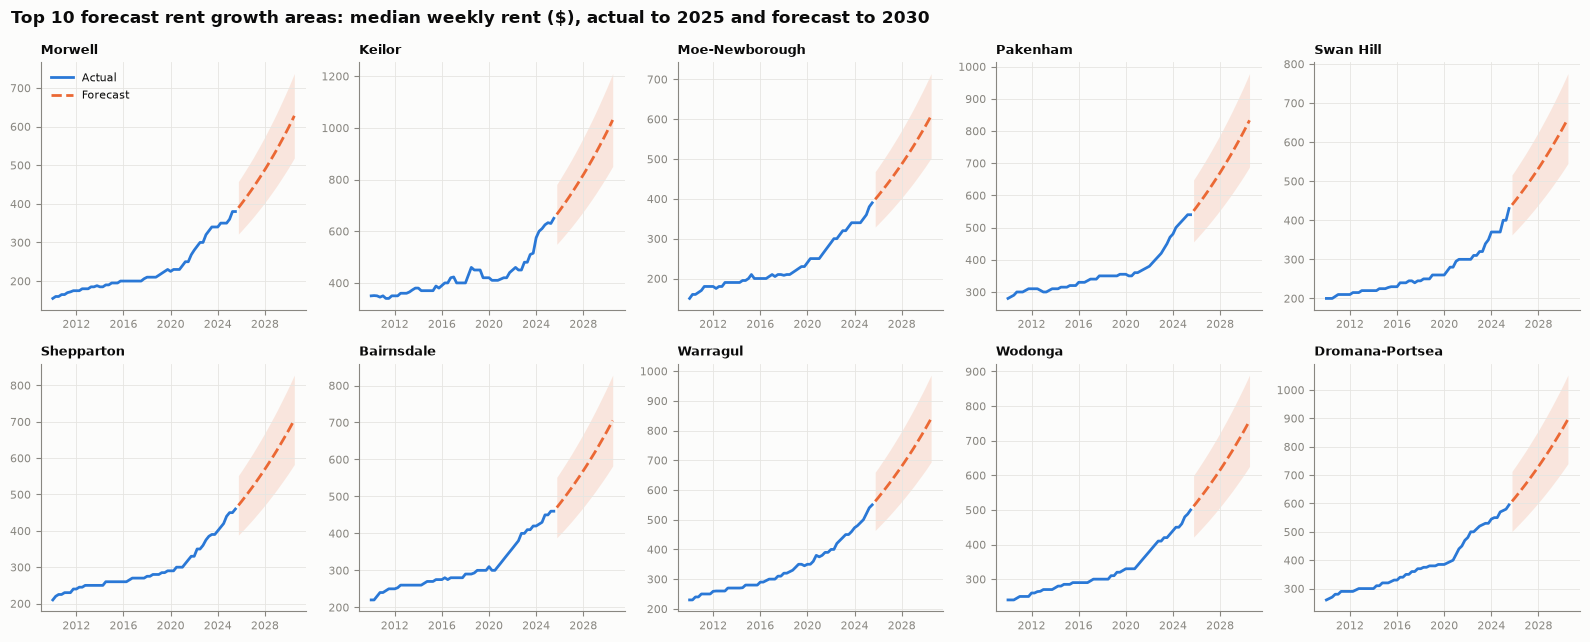

In [5]:
top = areas.head(10)["area"].tolist()
fig, axes = plt.subplots(2, 5, figsize=(16, 6.5), sharey=False)
for ax, area in zip(axes.flat, top):
    g = long[long["area"] == area]
    a, f = g[g["kind"] == "actual"], g[g["kind"] == "forecast"]
    ax.plot(a["quarter"].dt.to_timestamp(), a["rent"], color=style.BLUE, label="Actual")
    t = f["quarter"].dt.to_timestamp()
    ax.plot(t, f["rent"], color=style.ORANGE, linestyle="--", label="Forecast")
    ax.fill_between(t, f["rent"] * (1 - band / 100), f["rent"] * (1 + band / 100), color=style.ORANGE, alpha=0.15, linewidth=0)
    ax.set_title(area if len(area) < 28 else area[:26] + "…", fontsize=9)
    ax.tick_params(labelsize=8)
axes.flat[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Top 10 forecast rent growth areas: median weekly rent ($), actual to 2025 and forecast to 2030",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
fig.savefig(config.PLOTS / "forecast_top10_areas.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. From areas to suburbs

Each listing suburb gets its DFFH area's forecast growth. Suburbs outside the DFFH areas take the growth of the
nearest suburb that has one (`forecast_basis` says which). The suburb's forecast rent in 2030 is its **current
median listing rent** (latest snapshot) grown at that rate.

In [6]:
xw = pd.read_csv(config.DFFH_CROSSWALK).dropna(subset=["suburb_key"]).drop_duplicates("suburb_key")
sub = pd.read_parquet(config.SUBURB_FEATURES)
latest = sub[sub["snapshot"] == sub["snapshot"].max()].set_index("suburb_key")

direct = (xw.merge(areas, left_on="dffh_area", right_on="area")
            .set_index("suburb_key")[["area", "growth_pa_pct"]])
latest = latest.join(direct, how="left")
latest["forecast_basis"] = np.where(latest["growth_pa_pct"].notna(), "own DFFH area", None)

donors = latest[latest["growth_pa_pct"].notna()].reset_index().rename(columns={"suburb_key": "name"})
need = latest[latest["growth_pa_pct"].isna()]
near = geo.nearest(need, donors, "donor")
latest.loc[need.index, "area"] = donors.set_index("name").loc[near["nearest_donor"], "area"].to_numpy()
latest.loc[need.index, "growth_pa_pct"] = donors.set_index("name").loc[near["nearest_donor"], "growth_pa_pct"].to_numpy()
latest.loc[need.index, "forecast_basis"] = "nearest area (" + near["donor_km"].round(0).astype(int).astype(str) + " km)"

latest["rent_2030"] = latest["median_rent"] * (1 + latest["growth_pa_pct"] / 100) ** 5
latest["rent_2030_low"] = latest["rent_2030"] * (1 - band / 100)
latest["rent_2030_high"] = latest["rent_2030"] * (1 + band / 100)
out = latest.reset_index()[["suburb_key", "suburb", "postcode", "snapshot", "listings", "median_rent", "area",
                            "forecast_basis", "growth_pa_pct", "rent_2030", "rent_2030_low", "rent_2030_high",
                            "POP_PROJ_GROWTH_2026_2031", "lat", "lon"]]
out.to_parquet(config.FORECAST, index=False)
print(out["forecast_basis"].str.startswith("own").value_counts().rename({True: "own DFFH area", False: "nearest area"}))
print("\nTop 10 suburbs by forecast growth (own DFFH area, at least 10 listings)")
(out[out["forecast_basis"].eq("own DFFH area") & (out["listings"] >= 10)]
    .nlargest(10, "growth_pa_pct")
    [["suburb", "area", "median_rent", "rent_2030", "growth_pa_pct", "POP_PROJ_GROWTH_2026_2031"]]
    .round(3).reset_index(drop=True))

forecast_basis
nearest area     440
own DFFH area    204
Name: count, dtype: int64

Top 10 suburbs by forecast growth (own DFFH area, at least 10 listings)


,suburb,area,median_rent,rent_2030,growth_pa_pct,POP_PROJ_GROWTH_2026_2031
0,MORWELL,Morwell,400.0,660.870,10.563,0.003
1,MOE,Moe-Newborough,390.0,608.400,9.301,0.005
2,NEWBOROUGH,Moe-Newborough,467.5,729.300,9.301,0.005
3,PAKENHAM,Pakenham,560.0,864.000,9.060,0.006
4,BAIRNSDALE,Bairnsdale,450.0,690.000,8.925,0.005
5,SHEPPARTON,Shepparton,500.0,766.667,8.925,0.002
6,WARRAGUL,Warragul,580.0,886.111,8.846,0.028
7,DROMANA,Dromana-Portsea,627.5,945.222,8.539,0.011
8,BERWICK,Berwick,610.0,915.000,8.447,0.030
9,NORTH BENDIGO,North Bendigo,520.0,780.000,8.447,-0.008


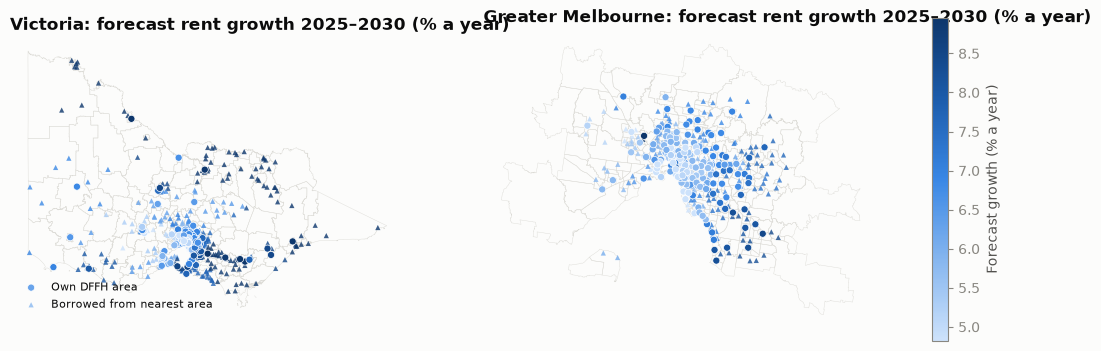

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sa2 = geo.load_sa2_vic()
lo, hi = out["growth_pa_pct"].quantile([0.05, 0.95])
for ax, box, title in [(axes[0], None, "Victoria"), (axes[1], (144.55, 145.45, -38.15, -37.55), "Greater Melbourne")]:
    pts = out if box is None else out[out["lon"].between(box[0], box[1]) & out["lat"].between(box[2], box[3])]
    base = sa2 if box is None else sa2.cx[box[0]:box[1], box[2]:box[3]]
    base.boundary.plot(ax=ax, color="#dcdbd6", linewidth=0.3)
    own = pts["forecast_basis"].eq("own DFFH area")
    sc = ax.scatter(pts.loc[own, "lon"], pts.loc[own, "lat"], c=pts.loc[own, "growth_pa_pct"], cmap=style.SEQ,
                    vmin=lo, vmax=hi, s=26, edgecolor="white", linewidth=0.5, zorder=3, label="Own DFFH area")
    ax.scatter(pts.loc[~own, "lon"], pts.loc[~own, "lat"], c=pts.loc[~own, "growth_pa_pct"], cmap=style.SEQ,
               vmin=lo, vmax=hi, s=14, marker="^", edgecolor="none", alpha=0.8, zorder=2, label="Borrowed from nearest area")
    ax.set_title(f"{title}: forecast rent growth 2025–2030 (% a year)")
    ax.set_axis_off()
fig.colorbar(sc, ax=axes, shrink=0.7, label="Forecast growth (% a year)")
axes[0].legend(loc="lower left", fontsize=8)
fig.savefig(config.PLOTS / "map_forecast_growth.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Check against the newer snapshot (runs automatically once 2026 data is added)

In [8]:
snaps = sorted(sub["snapshot"].unique())
if len(snaps) < 2:
    print(f"Only the {snaps[0]} snapshot is loaded. Once the rent.com.au 2026 data is added, this cell compares each "
          "suburb's actual one-year change in median listing rent with the forecast growth.")
else:
    wide = sub[sub["listings"] >= 10].pivot_table(index="suburb_key", columns="snapshot", values="median_rent")
    change = (wide[snaps[-1]] / wide[snaps[0]] - 1).mul(100).rename("actual_change_pct").dropna()
    check = out.set_index("suburb_key").join(change, how="inner")
    print(f"{len(check)} suburbs in both snapshots")
    print(f"Median actual change: {check['actual_change_pct'].median():.1f}% vs forecast {check['growth_pa_pct'].median():.1f}% a year")
    print(f"Rank correlation (actual vs forecast growth): {check[['actual_change_pct', 'growth_pa_pct']].corr('spearman').iloc[0, 1]:.2f}")
    print("Note: the snapshots come from different websites, so part of the change is a website difference.")

Only the 2025-09 snapshot is loaded. Once the rent.com.au 2026 data is added, this cell compares each suburb's actual one-year change in median listing rent with the forecast growth.
